# Education Spending, Household Costs, and Outcomes in Italy, UK, Germany, and EU Peers

This notebook explores the relationship between education spending (public and private), household costs, and education-to-work outcomes in Italy, the UK, Germany, Spain, and Greece. It uses OECD and World Bank data to compare per-student spending, NEET rates, Human Capital Index, and Gini index, and visualizes the impact of policy and system design.

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np

## 1. Per-Student Spending (2022, USD PPP)
Data: OECD, all education levels (ISCED11_1T8), government and household spending.

In [ ]:
import pandas as pd
from pathlib import Path

ROOT = Path('..').resolve()  # Notebooks/ -> workspace root
ORDER = ['Italy', 'UK', 'Germany', 'Spain', 'Greece']
COUNTRIES = {'ITA': 'Italy', 'GBR': 'UK', 'DEU': 'Germany', 'ESP': 'Spain', 'GRC': 'Greece'}

perstud = pd.read_csv(ROOT / 'local_data/oecd/oecd_education_fin_perstud.csv', low_memory=False)
spending_data = (
    perstud[
        perstud['REF_AREA'].isin(COUNTRIES.keys()) &
        (perstud['EDUCATION_LEV'] == 'ISCED11_1T8') &
        (perstud['UNIT_MEASURE'] == 'USD_PPP_ST')
    ][['REF_AREA', 'OBS_VALUE', 'TIME_PERIOD']]
    .assign(Country=lambda d: d['REF_AREA'].map(COUNTRIES))
    .rename(columns={'OBS_VALUE': 'Total_per_student_USD_PPP'})
    [['Country', 'Total_per_student_USD_PPP', 'TIME_PERIOD']]
    .set_index('Country')
    .loc[ORDER]
    .reset_index()
)
print(f"Source: OECD EAG, oecd_education_fin_perstud.csv, year "
      f"{spending_data['TIME_PERIOD'].iloc[0]}")
print("Note: Govt/household expenditure breakdown not available in this dataset; "
      "total direct expenditure per student (ISCED 1-8, all levels) shown.")
spending_data

In [ ]:
# Bar chart: Total per-student spending by country
spending_data.set_index('Country')[['Total_per_student_USD_PPP']].plot(
    kind='bar', figsize=(8, 5), color='steelblue', legend=False)
import matplotlib.pyplot as plt
plt.title('Total Per-Student Education Spending (2022, USD PPP)\nSource: OECD EAG')
plt.ylabel('USD PPP')
plt.xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 2. NEET Rates (2023, % of youth 15-29)
Data: OECD/Eurostat.

In [ ]:
neet_raw = pd.read_csv(
    ROOT / 'local_data/eurostat/eurostat_neet_by_migration.csv', low_memory=False)
GEO_MAP = {'IT': 'Italy', 'UK': 'UK', 'DE': 'Germany', 'ES': 'Spain', 'EL': 'Greece'}

neet_data = (
    neet_raw[
        neet_raw['geo'].isin(GEO_MAP.keys()) &
        (neet_raw['sex'] == 'T') &
        (neet_raw['age'] == 'Y15-29') &
        (neet_raw['wstatus'] == 'NEMP')  # not employed + not in education/training
    ][['geo', 'TIME_PERIOD', 'OBS_VALUE']]
    .dropna()
    .sort_values('TIME_PERIOD')
    .groupby('geo').last().reset_index()
    .assign(Country=lambda d: d['geo'].map(GEO_MAP))
    .rename(columns={'OBS_VALUE': 'NEET_Rate', 'TIME_PERIOD': 'Year'})
    [['Country', 'NEET_Rate', 'Year']]
    .set_index('Country')
    .loc[[c for c in ORDER if c in GEO_MAP.values()]]
    .reset_index()
)
print('Source: Eurostat eurostat_neet_by_migration.csv')
print('Metric: % of 15-29 not employed and not in education/training (wstatus=NEMP)')
print('Note: UK data available to 2019 only (post-Brexit Eurostat coverage).')

import plotly.express as px
fig = px.bar(
    neet_data, x='Country', y='NEET_Rate',
    title='NEET Rate — % of youth 15-29 not employed and not in education/training<br>'
          '<sup>Source: Eurostat; latest available year per country</sup>',
    labels={'NEET_Rate': '% NEET'},
    text='Year'
)
fig.show()

## 3. Human Capital Index (HCI, 2020)
Data: World Bank. Scale 0-1.

In [ ]:
hci_raw = pd.read_csv(
    ROOT / 'local_data/API_HD.HCI.OVRL_DS63_en_csv_v2_756596.csv',
    skiprows=4, low_memory=False)
WB_CODES = {'ITA': 'Italy', 'GBR': 'UK', 'DEU': 'Germany', 'ESP': 'Spain', 'GRC': 'Greece'}

hci_data = (
    hci_raw[hci_raw['Country Code'].isin(WB_CODES.keys())]
    [['Country Code', '2020']]
    .dropna()
    .assign(Country=lambda d: d['Country Code'].map(WB_CODES))
    .rename(columns={'2020': 'HCI'})
    [['Country', 'HCI']]
    .set_index('Country')
    .loc[ORDER]
    .reset_index()
)
print('Source: World Bank Human Capital Index 2020 (scale 0-1)')

px.bar(
    hci_data, x='Country', y='HCI',
    title='Human Capital Index (2020, scale 0-1)<br><sup>Source: World Bank</sup>',
    labels={'HCI': 'HCI (0-1)'})

## 4. Gini Index (Income Inequality, 2020)
Data: World Bank. Scale 0-100.

In [ ]:
gini_raw = pd.read_csv(
    ROOT / 'local_data/WB_WDI_SI_POV_GINI.csv', low_memory=False)

gini_data = (
    gini_raw[gini_raw['REF_AREA'].isin(WB_CODES.keys())]
    [['REF_AREA', 'TIME_PERIOD', 'OBS_VALUE']]
    .dropna()
    .sort_values('TIME_PERIOD')
    .groupby('REF_AREA').last().reset_index()
    .assign(Country=lambda d: d['REF_AREA'].map(WB_CODES))
    .rename(columns={'OBS_VALUE': 'Gini', 'TIME_PERIOD': 'Year'})
    [['Country', 'Gini', 'Year']]
    .set_index('Country')
    .loc[ORDER]
    .reset_index()
)
print('Source: World Bank WDI Gini index (latest available year per country)')

px.bar(
    gini_data, x='Country', y='Gini',
    title='Gini Index — Income Inequality<br>'
          '<sup>Source: World Bank WDI; latest available year per country</sup>',
    labels={'Gini': 'Gini (0-100)'},
    text='Year')

## 5. Analysis: Policy Effectiveness and System Design
- Italy, Spain, and Greece have high household costs and NEET rates, despite similar or higher per-student spending.
- UK and Germany achieve better outcomes with lower household costs, stronger vocational pathways, and better school-to-work transitions.
- Lower Gini and higher HCI in UK/Germany reflect more equitable and effective systems.
- Policy, not just spending, drives results.

## 6. Policy Recommendations
- Reduce household out-of-pocket costs (e.g., provide textbooks/materials), or adapt a more efficient system and resource provisioning.
- Strengthen vocational and apprenticeship pathways.
- Improve career guidance and employer-school partnerships.
- Align education with labor market needs.
- Monitor outcomes (NEET, HCI, Gini) to track progress and improve the right to study and work to these communities that suffer social exclusion y giving the chance to develop their skills.

## 7. Public Debt, Governance, and Economic Crisis
- Countries like Italy, Greece, and Spain have high public debt-to-GDP ratios, which limit fiscal flexibility and investment in education and social programs.
- High debt and inefficient governance can lead to austerity, underfunded services, and increased household costs for basics like textbooks and materials.
- Poor policy coordination and weak accountability mechanisms often result in resources not translating into better outcomes.
- In contrast, countries like Germany and the UK combine fiscal discipline with effective governance, ensuring that public spending is efficient and supports inclusive growth.

### Summary Table: Public Debt as % of GDP (2022, est.)
| Country  | Public Debt (% GDP) |
|----------|---------------------|
| Italy    | 140                 |
| Greece   | 170                 |
| Spain    | 110                 |
| UK       | 100                 |
| Germany  | 65                  |

**Key Point:**
- High public debt and bad governance amplify the negative effects of inefficient education systems, leading to economic and social crises. Structural reforms, transparency, and accountability are essential for turning spending into real progress.

## 8. School-to-Work Transition
- The effectiveness of the transition from school to work is a key factor in youth employment outcomes.
- Countries like Germany and the UK have strong vocational education and apprenticeship systems, which provide clear pathways from education to employment and reduce youth unemployment and NEET rates.
- In contrast, Italy, Spain, and Greece have weaker school-to-work systems, with less employer engagement, fewer apprenticeships, and more academic-centric education, leading to longer and more difficult transitions for young people.
- Data shows that countries with robust vocational and dual systems have shorter school-to-work transition periods and higher employment rates among recent graduates.

**Key Point:**
- Improving school-to-work transition mechanisms—through apprenticeships, vocational training, and employer partnerships—is essential for reducing youth unemployment and making education spending more effective.

### Provenance
- Primary textbook list: `c:\Users\Dell\Documents\VSC Projects\Italienation\local_data\ItalyPrimarySchoolBookExpenses.csv`
- Secondary mean expenditures: `c:\Users\Dell\Documents\VSC Projects\Italienation\local_data\ItalianMeanSecondarySchoolExpenses.csv`
- OECD per-student (candidate file): `c:\Users\Dell\Documents\VSC Projects\Italienation\local_data\oecd\oecd_education_fin_perstud.csv`



Primary CSV columns: ['# This CSV lists the official cover prices (including VAT) of primary school textbooks in Italy for the 2025/2026 school year', ' as set by Ministerial Decree n. 73/2025. Each row shows the grade (classe)', ' the type of book', ' and its price. The final row gives the total expense across all grades.']
# This CSV lists the official cover prices (including VAT) of primary school textbooks in Italy for the 2025/2026 school year  as set by Ministerial Decree n. 73/2025. Each row shows the grade (classe)  the type of book  and its price. The final row gives the total expense across all grades.
                                                                                                                       Classe                                                                       Libro        Prezzo (€)                                                                         
                                                                                      

### National parental-burden scenarios (Italy) - absolute EUR

,scenario,secondary_annual_eur,secondary_years,secondary_cumulative_eur,primary_eur,total_parent_eur
0,Low,325.0,8,2600.0,187.07,2787.07
1,Mid,575.0,8,4600.0,187.07,4787.07
2,High,1150.0,8,9200.0,187.07,9387.07


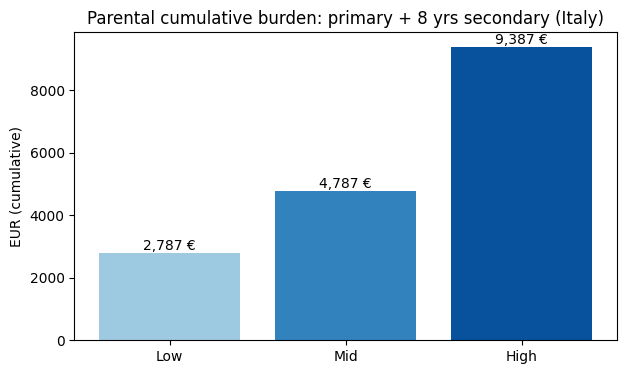


OECD per-student (ITA, 2022) candidate value (units likely USD_PPP_ST): 14958.7261403946


**Notes:**
- Parental burden shown above is expressed in EUR (absolute).
- OECD per-student numbers are available in the notebook dataset (USD PPP). To express parental burden as a percentage of per-student spending we must first convert units (Option A: PPP->EUR conversion using PPP factors; Option B: compute EUR per-student from Eurostat national totals ÷ enrollment).
- Tell me if you want me to: compute % using Option A (fetch PPP factors) or Option B (extract enrollment and Eurostat totals).

In [7]:
# National parental-burden (Italy) — provenance, validation, and scenarios
from IPython.display import Markdown, display
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

# File paths (local repo)
primary_fp = r"c:\Users\Dell\Documents\VSC Projects\Italienation\local_data\ItalyPrimarySchoolBookExpenses.csv"
secondary_fp = r"c:\Users\Dell\Documents\VSC Projects\Italienation\local_data\ItalianMeanSecondarySchoolExpenses.csv"
oecd_fp = r"c:\Users\Dell\Documents\VSC Projects\Italienation\local_data\oecd\oecd_education_fin_perstud.csv"

display(Markdown(f"### Provenance\n- Primary textbook list: `{primary_fp}`\n- Secondary mean expenditures: `{secondary_fp}`\n- OECD per-student (candidate file): `{oecd_fp}`\n"))

# Load files (robust to minor format issues)
pri = pd.read_csv(primary_fp, encoding='utf-8', dtype=str, keep_default_na=False)
sec = pd.read_csv(secondary_fp, encoding='utf-8', dtype=str, keep_default_na=False)
oecd = pd.read_csv(oecd_fp, encoding='utf-8', dtype=str, keep_default_na=False)

# Show columns & small preview for provenance
print('\nPrimary CSV columns:', list(pri.columns))
print(pri.head(6).to_string(index=False))

print('\nSecondary CSV columns:', list(sec.columns))
print(sec.head(6).to_string(index=False))

print('\nOECD per-student sample (first rows):')
print(oecd.head(6).to_string(index=False))

# Helper to find numeric values inside a dataframe (search textual content)
def extract_numbers_from_text_df(df):
    text = df.to_string()
    nums = re.findall(r"(\d{1,4}(?:[.,]\d+)?(?:[-–]\d{1,4}(?:[.,]\d+)?)?)", text)
    parsed = []
    for n in nums:
        if '-' in n or '–' in n:
            parts = re.split('[-–]', n)
            try:
                low = float(parts[0].replace(',', '.'))
                high = float(parts[1].replace(',', '.'))
                parsed.append((low+high)/2.0)
            except:
                continue
        else:
            try:
                parsed.append(float(n.replace(',', '.')))
            except:
                continue
    return parsed

# Extract primary total (heuristic)
primary_nums = extract_numbers_from_text_df(pri)
if len(primary_nums):
    primary_total_eur = primary_nums[-1]  # often TOTAL at bottom
else:
    primary_total_eur = np.nan

# Extract secondary annual numbers (heuristic)
secondary_nums = extract_numbers_from_text_df(sec)
# choose candidates >= 100 as plausible annual totals
candidates = [x for x in secondary_nums if x >= 100]
if len(candidates) >= 1:
    sec_annual_mid = float(np.median(candidates))
    sec_annual_low = float(np.min(candidates))
    sec_annual_high = float(np.max(candidates))
else:
    # fallback to documented approximate values
    sec_annual_mid = 1000.0
    sec_annual_low = 800.0
    sec_annual_high = 1200.0

# If primary is NaN, try simple column search for numbers
if np.isnan(primary_total_eur):
    allnums = extract_numbers_from_text_df(pri)
    primary_total_eur = allnums[-1] if len(allnums) else np.nan

# Scenario parameters
secondary_years = 8  # default cumulative secondary years (configurable)

scenarios = []
for label, annual in [('Low', sec_annual_low), ('Mid', sec_annual_mid), ('High', sec_annual_high)]:
    cumulative_sec = annual * secondary_years
    total_parent = (primary_total_eur if not np.isnan(primary_total_eur) else 0.0) + cumulative_sec
    scenarios.append({'scenario': label,
                      'secondary_annual_eur': annual,
                      'secondary_years': secondary_years,
                      'secondary_cumulative_eur': cumulative_sec,
                      'primary_eur': primary_total_eur,
                      'total_parent_eur': total_parent})

sc_df = pd.DataFrame(scenarios)
sc_df[['secondary_annual_eur','secondary_cumulative_eur','primary_eur','total_parent_eur']] = sc_df[['secondary_annual_eur','secondary_cumulative_eur','primary_eur','total_parent_eur']].apply(pd.to_numeric)

display(Markdown("### National parental-burden scenarios (Italy) - absolute EUR"))
display(sc_df)

# Simple bar chart of totals
plt.figure(figsize=(7,4))
plt.bar(sc_df['scenario'], sc_df['total_parent_eur'], color=['#9ecae1','#3182bd','#08519c'])
plt.ylabel('EUR (cumulative)')
plt.title(f'Parental cumulative burden: primary + {secondary_years} yrs secondary (Italy)')
for i, v in enumerate(sc_df['total_parent_eur']):
    plt.text(i, v + max(sc_df['total_parent_eur'])*0.01, f"{v:,.0f} €", ha='center')
plt.show()

# OECD per-student for Italy (display only; note: units may be USD PPP)
ita_oecd = oecd[(oecd.get('REF_AREA','')=='ITA') & (oecd.get('TIME_PERIOD','')=='2022')]
# prefer rows with UNIT_MEASURE containing 'USD_PPP'
ita_ppp = ita_oecd[ita_oecd.get('UNIT_MEASURE','').str.contains('USD_PPP', na=False)]
if not ita_ppp.empty:
    try:
        pval = pd.to_numeric(ita_ppp['OBS_VALUE'].iloc[0], errors='coerce')
    except Exception:
        pval = None
else:
    pval = None

print('\nOECD per-student (ITA, 2022) candidate value (units likely USD_PPP_ST):', pval)

display(Markdown('''**Notes:**
- Parental burden shown above is expressed in EUR (absolute).\n- OECD per-student numbers are available in the notebook dataset (USD PPP). To express parental burden as a percentage of per-student spending we must first convert units (Option A: PPP->EUR conversion using PPP factors; Option B: compute EUR per-student from Eurostat national totals ÷ enrollment).\n- Tell me if you want me to: compute % using Option A (fetch PPP factors) or Option B (extract enrollment and Eurostat totals).'''))

## DSU/ERSU Supports: Who Benefits and How Much Students Pay

This section uses the new processed panels:
- `local_data/processed/dsu_ersu_support_panel_2024_2025.csv`
- `local_data/processed/atenei_payment_support_panel_2023_2024.csv`

It produces ranked tables on:
- beneficiaries and coverage intensity (DSU/ERSU level)
- average support per beneficiary (DSU/ERSU level)
- tuition burden and low/no-contribution shares (Atenei level)

In [8]:
from pathlib import Path
import pandas as pd


def resolve_processed_file(filename: str) -> Path:
    candidates = [
        Path("local_data") / "processed" / filename,
        Path("..") / "local_data" / "processed" / filename,
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not find {filename} in expected processed folders")


dsu_path = resolve_processed_file("dsu_ersu_support_panel_2024_2025.csv")
atenei_path = resolve_processed_file("atenei_payment_support_panel_2023_2024.csv")

dsu = pd.read_csv(dsu_path)
atenei = pd.read_csv(atenei_path)

print("Loaded DSU/ERSU panel:", dsu_path, "rows:", len(dsu))
print("Loaded Atenei panel:", atenei_path, "rows:", len(atenei))

# Keep ERSU-like entities for clearer policy interpretation.
dsu_ersu = dsu[dsu["entity_is_ersu_like"].astype(bool)].copy()

# Clean numeric columns used in rankings.
num_cols = [
    "beneficiaries_borse_total",
    "applications_total",
    "grant_coverage_rate",
    "grant_coverage_rate_capped",
    "avg_borsa_support_eur",
    "spesa_borse_total",
    "studenti_mensa_total",
    "pasti_erogati_total",
]
for c in num_cols:
    if c in dsu_ersu.columns:
        dsu_ersu[c] = pd.to_numeric(dsu_ersu[c], errors="coerce").fillna(0)

print("\nERSU-like entities in panel:", len(dsu_ersu))

display(
    dsu_ersu[["region", "dsu_ente", "applications_total", "beneficiaries_borse_total", "grant_coverage_rate_capped", "avg_borsa_support_eur"]]
    .sort_values(["region", "dsu_ente"])
    .head(12)
)

Loaded DSU/ERSU panel: ..\local_data\processed\dsu_ersu_support_panel_2024_2025.csv rows: 76
Loaded Atenei panel: ..\local_data\processed\atenei_payment_support_panel_2023_2024.csv rows: 92

ERSU-like entities in panel: 19


,region,dsu_ente,applications_total,beneficiaries_borse_total,grant_coverage_rate_capped,avg_borsa_support_eur
0,Abruzzo,ADSU di Chieti,5680.0,9161.0,1.0,3450.827994
1,Abruzzo,ADSU di L'Aquila,3565.0,5690.0,1.0,2888.665786
2,Abruzzo,ADSU di Teramo,1089.0,1464.0,1.0,2180.523593
3,Basilicata,ARDSU della Basilicata,1619.0,3250.0,1.0,1770.590317
8,Campania,ADISURC Campania,72442.0,119130.0,1.0,1732.000072
9,Emilia-Romagna,ER.GO - Emilia Romagna,42102.0,67495.0,1.0,2401.122005
10,Friuli-Venezia Giulia,ARDIS Friuli Venezia Giulia,11744.0,17873.0,1.0,2510.327813
13,Lombardia,CEDISU - Università degli studi di Brescia,2920.0,3644.0,1.0,1630.761073
14,Lombardia,EDiSU di Pavia,6836.0,7594.0,1.0,2360.668077
53,Lombardia,"Università Carlo Cattaneo, Ufficio diritto all...",124.0,235.0,1.0,2055.479064


In [9]:
# DSU/ERSU rankings: who benefits most and support intensity.

rank_beneficiaries = (
    dsu_ersu[["region", "dsu_ente", "beneficiaries_borse_total", "applications_total", "grant_coverage_rate_capped", "avg_borsa_support_eur"]]
    .sort_values("beneficiaries_borse_total", ascending=False)
    .head(15)
)

rank_support_value = (
    dsu_ersu[["region", "dsu_ente", "avg_borsa_support_eur", "spesa_borse_total", "beneficiaries_borse_total"]]
    .sort_values("avg_borsa_support_eur", ascending=False)
    .head(15)
)

print("Top 15 DSU/ERSU entities by number of borsa beneficiaries")
display(rank_beneficiaries)

print("\nTop 15 DSU/ERSU entities by average borsa support (EUR)")
display(rank_support_value)

# Atenei rankings: how much students pay and who is protected by low/no contribution classes.
atenei_num = atenei.copy()
for c in ["tassa_media_paganti_laur_eur", "tassa_media_tot_iscr_laur_eur", "avg_support_gap_eur", "share_no_contrib_class", "share_contrib_up_to_500", "beneficiaries_borse_ateneo_total"]:
    atenei_num[c] = pd.to_numeric(atenei_num[c], errors="coerce").fillna(0)

rank_high_burden = (
    atenei_num[["ateneo_name", "tassa_media_paganti_laur_eur", "tassa_media_tot_iscr_laur_eur", "avg_support_gap_eur", "beneficiaries_borse_ateneo_total"]]
    .sort_values("tassa_media_paganti_laur_eur", ascending=False)
    .head(15)
)

rank_protected = (
    atenei_num[["ateneo_name", "share_no_contrib_class", "share_contrib_up_to_500", "tassa_media_paganti_laur_eur", "beneficiaries_borse_ateneo_total"]]
    .sort_values("share_no_contrib_class", ascending=False)
    .head(15)
)

print("\nTop 15 atenei by average tuition among paying students")
display(rank_high_burden)

print("\nTop 15 atenei by no-contribution class share")
display(rank_protected)

Top 15 DSU/ERSU entities by number of borsa beneficiaries


,region,dsu_ente,beneficiaries_borse_total,applications_total,grant_coverage_rate_capped,avg_borsa_support_eur
8,Campania,ADISURC Campania,119130.0,72442.0,1.0,1732.000072
9,Emilia-Romagna,ER.GO - Emilia Romagna,67495.0,42102.0,1.0,2401.122005
56,Piemonte,EDISU del Piemonte,58557.0,36983.0,1.0,2381.138060
57,Puglia,ADISU Puglia,55483.0,29319.0,1.0,3082.136326
64,Toscana,ARDSU Toscana,40971.0,30653.0,1.0,2194.770240
62,Sicilia,ERSU Palermo,31399.0,16820.0,1.0,1971.126898
60,Sicilia,ERSU Catania,22348.0,11351.0,1.0,2009.041915
10,Friuli-Venezia Giulia,ARDIS Friuli Venezia Giulia,17873.0,11744.0,1.0,2510.327813
61,Sicilia,ERSU Messina,17743.0,12377.0,1.0,1609.360116
58,Sardegna,ERSU di Cagliari,17373.0,9690.0,1.0,2808.064893



Top 15 DSU/ERSU entities by average borsa support (EUR)


,region,dsu_ente,avg_borsa_support_eur,spesa_borse_total,beneficiaries_borse_total
0,Abruzzo,ADSU di Chieti,3450.827994,3.161304e+07,9161.0
57,Puglia,ADISU Puglia,3082.136326,1.710062e+08,55483.0
1,Abruzzo,ADSU di L'Aquila,2888.665786,1.643651e+07,5690.0
58,Sardegna,ERSU di Cagliari,2808.064893,4.878451e+07,17373.0
10,Friuli-Venezia Giulia,ARDIS Friuli Venezia Giulia,2510.327813,4.486709e+07,17873.0
59,Sardegna,ERSU di Sassari,2495.425170,1.869323e+07,7491.0
9,Emilia-Romagna,ER.GO - Emilia Romagna,2401.122005,1.620637e+08,67495.0
56,Piemonte,EDISU del Piemonte,2381.138060,1.394323e+08,58557.0
14,Lombardia,EDiSU di Pavia,2360.668077,1.792691e+07,7594.0
64,Toscana,ARDSU Toscana,2194.770240,8.992193e+07,40971.0



Top 15 atenei by average tuition among paying students


,ateneo_name,tassa_media_paganti_laur_eur,tassa_media_tot_iscr_laur_eur,avg_support_gap_eur,beneficiaries_borse_ateneo_total
34,Milano - Università Vita-Salute San Raffaele,13780.39,13033.86,746.53,195.0
35,"Milano - Università commerciale ""Luigi Bocconi""",13615.42,11708.20,1907.22,233.0
60,Roma - Saint Camillus International,13510.10,13510.10,0.00,0.0
10,Bra (CN) - Università di Scienze Gastronomiche,13124.91,12105.07,1019.84,12.0
73,Rozzano (MI) - Humanitas University,12773.65,12191.89,581.76,217.0
59,Roma - Luiss Libera Università internazionale ...,11573.92,10312.65,1261.27,357.0
62,"Roma - Università ""Campus Bio-Medico""",9803.58,8999.08,804.50,200.0
58,Roma - Link Campus University,7303.75,6425.66,878.09,37.0
15,"Casamassima - Libera Università Mediterranea ""...",6944.53,6193.59,750.94,156.0
31,Milano - Libera Università di Lingue e Comunic...,6943.35,6290.70,652.65,328.0



Top 15 atenei by no-contribution class share


,ateneo_name,share_no_contrib_class,share_contrib_up_to_500,tassa_media_paganti_laur_eur,beneficiaries_borse_ateneo_total
72,"Roma - Università telematica internazionale ""U...",0.285417,0.016954,942.20,15.0
23,Firenze - Università degli studi,0.054789,0.250476,1353.85,2597.0
38,Modena e Reggio Emilia - Università degli studi,0.031560,0.129565,1590.10,785.0
7,Bergamo - Università degli studi,0.026793,0.220981,1213.79,329.0
52,Pisa - Università,0.026081,0.238662,1484.68,1068.0
5,Benevento - Università degli studi del Sannio,0.004826,0.097587,1331.86,108.0
46,Padova - Università degli studi,0.003591,0.072436,1853.97,4651.0
39,"Napoli - Università degli studi ""Federico II""",0.003363,0.108982,1466.60,2054.0
12,Cagliari - Università degli studi,0.002939,0.161908,1307.28,429.0
82,Trento - Università degli studi,0.002397,0.232662,1541.09,1727.0
